# Android Malware Detection 데이터셋 EDA

- 데이터셋: **TUANDROMD.csv**
- 목적: Android 앱의 Permission/API 기반 feature를 이용해 `malware`와 `goodware`의 차이를 탐색한다.
- 분석 흐름:
  1. 데이터 로드 및 구조 확인
  2. 결측치/중복값 확인
  3. Target 분포 확인
  4. Permission/API feature 분리
  5. Feature 사용 비율 분석
  6. Malware/Goodware별 feature 차이 분석
  7. Feature count 및 상관관계 분석
  8. EDA 결과 요약


In [2]:

# ============================================================
# 0. 라이브러리 및 기본 설정
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set(style="whitegrid")

# 주피터 노트북에서 표를 보기 좋게 출력하기 위한 설정
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


## 1. 데이터 로드

`TUANDROMD.csv` 파일이 노트북과 같은 폴더에 있으면 그대로 읽고, 그렇지 않으면 `/mnt/data/TUANDROMD.csv` 경로를 사용하도록 구성했다.


In [3]:

# ============================================================
# 1. 데이터 불러오기
# ============================================================

local_path = "TUANDROMD.csv"
uploaded_path = "/mnt/data/TUANDROMD.csv"

if os.path.exists(local_path):
    DATA_PATH = local_path
elif os.path.exists(uploaded_path):
    DATA_PATH = uploaded_path
else:
    raise FileNotFoundError("TUANDROMD.csv 파일을 찾을 수 없습니다. 노트북과 같은 폴더에 파일을 넣어주세요.")

df = pd.read_csv(DATA_PATH)

print("데이터 경로:", DATA_PATH)
print("데이터 크기:", df.shape)

display(df.head())


데이터 경로: TUANDROMD.csv
데이터 크기: (4465, 242)


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,ACCESS_PROVIDER,ACCESS_SERVICE,ACCESS_SHARED_DATA,ACCESS_SUPERUSER,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,activityCalled,ACTIVITY_RECOGNITION,ACCOUNT_MANAGER,ADD_VOICEMAIL,ANT,ANT_ADMIN,AUTHENTICATE_ACCOUNTS,AUTORUN_MANAGER_LICENSE_MANAGER,AUTORUN_MANAGER_LICENSE_SERVICE(.autorun),BATTERY_STATS,BILLING,BIND_ACCESSIBILITY_SERVICE,BIND_APPWIDGET,BIND_CARRIER_MESSAGING_SERVICE,BIND_DEVICE_ADMIN,BIND_DREAM_SERVICE,BIND_GET_INSTALL_REFERRER_SERVICE,BIND_INPUT_METHOD,BIND_NFC_SERVICE,BIND_goodwareTIFICATION_LISTENER_SERVICE,BIND_PRINT_SERVICE,BIND_REMOTEVIEWS,BIND_TEXT_SERVICE,BIND_TV_INPUT,BIND_VOICE_INTERACTION,BIND_VPN_SERVICE,BIND_WALLPAPER,BLUETOOTH,BLUETOOTH_ADMIN,BLUETOOTH_PRIVILEGED,BODY_SENSORS,BRICK,BROADCAST_PACKAGE_REMOVED,BROADCAST_SMS,...,WRITE,WRITE_APN_SETTINGS,WRITE_AVSETTING,WRITE_CALENDAR,WRITE_CALL_LOG,WRITE_CONTACTS,WRITE_DATA,WRITE_DATABASES,WRITE_EXTERNAL_STORAGE,WRITE_GSERVICES,WRITE_HISTORY_BOOKMARKS,WRITE_INTERNAL_STORAGE,WRITE_MEDIA_STORAGE,WRITE_OWNER_DATA,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,WRITE_VOICEMAIL,Ljava/lang/reflect/Method;->invoke,Ljavax/crypto/Cipher;->doFinal,Ljava/lang/Runtime;->exec,Ljava/lang/System;->load,Ldalvik/system/DexClassLoader;->loadClass,Ljava/lang/System;->loadLibrary,Ljava/net/URL;->openConnection,Landroid/hardware/Camera;->open,Landroid/hardware/Camera;->takePicture,Landroid/telephony/SmsManager;->sendMultipartTextMessage,Landroid/telephony/SmsManager;->sendTextMessage,Landroid/media/AudioRecord;->startRecording,Landroid/telephony/TelephonyManager;->getCellLocation,Lcom/google/android/gms/location/LocationClient;->getLastLocation,Landroid/location/LocationManager;->getLastKgoodwarewnLocation,Landroid/telephony/TelephonyManager;->getDeviceId,Landroid/content/pm/PackageManager;->getInstalledApplications,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## 2. 데이터 기본 구조 확인

행/열 개수, 컬럼명, 자료형, 기초 통계량을 확인한다.


In [4]:

# ============================================================
# 2. 기본 정보 확인
# ============================================================

print("행 수:", len(df))
print("컬럼 수:", len(df.columns))

print("\n앞쪽 컬럼 10개:")
print(df.columns[:10].tolist())

print("\n뒤쪽 컬럼 10개:")
print(df.columns[-10:].tolist())

print("\n데이터 타입 개수:")
display(df.dtypes.value_counts())

print("\n데이터 정보:")
df.info()


행 수: 4465
컬럼 수: 242

앞쪽 컬럼 10개:
['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM', 'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION', 'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION', 'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE']

뒤쪽 컬럼 10개:
['Landroid/telephony/TelephonyManager;->getLine1Number', 'Landroid/telephony/TelephonyManager;->getNetworkOperator', 'Landroid/telephony/TelephonyManager;->getNetworkOperatorName', 'Landroid/telephony/TelephonyManager;->getNetworkCountryIso', 'Landroid/telephony/TelephonyManager;->getSimOperator', 'Landroid/telephony/TelephonyManager;->getSimOperatorName', 'Landroid/telephony/TelephonyManager;->getSimCountryIso', 'Landroid/telephony/TelephonyManager;->getSimSerialNumber', 'Lorg/apache/http/impl/client/DefaultHttpClient;->execute', 'Label']

데이터 타입 개수:


float64    241
object       1
Name: count, dtype: int64


데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(241), object(1)
memory usage: 8.2+ MB


In [5]:

# 기초 통계량 확인
display(df.describe().T.head(20))


,count,mean,std,min,25%,50%,75%,max
ACCESS_ALL_DOWNLOADS,4464.0,0.000896,0.029924,0.0,0.0,0.0,0.0,1.0
ACCESS_CACHE_FILESYSTEM,4464.0,0.000896,0.029924,0.0,0.0,0.0,0.0,1.0
ACCESS_CHECKIN_PROPERTIES,4464.0,0.004928,0.070037,0.0,0.0,0.0,0.0,1.0
ACCESS_COARSE_LOCATION,4464.0,0.083333,0.276416,0.0,0.0,0.0,0.0,1.0
ACCESS_COARSE_UPDATES,4464.0,0.006944,0.083053,0.0,0.0,0.0,0.0,1.0
ACCESS_FINE_LOCATION,4464.0,0.087814,0.283055,0.0,0.0,0.0,0.0,1.0
ACCESS_LOCATION_EXTRA_COMMANDS,4464.0,0.022849,0.149440,0.0,0.0,0.0,0.0,1.0
ACCESS_MOCK_LOCATION,4464.0,0.023746,0.152272,0.0,0.0,0.0,0.0,1.0
ACCESS_MTK_MMHW,4464.0,0.000224,0.014967,0.0,0.0,0.0,0.0,1.0
ACCESS_NETWORK_STATE,4464.0,0.596326,0.490689,0.0,0.0,1.0,1.0,1.0


## 3. Target 변수 확인

이 데이터셋의 target 변수는 `Label`이며, 값은 `malware`와 `goodware`로 구성된다.


In [6]:

# ============================================================
# 3. Target 변수 확인
# ============================================================

target_col = "Label"

print("Target 변수 고유값:")
print(df[target_col].unique())

print("\nTarget 변수 분포:")
label_count = df[target_col].value_counts(dropna=False)
display(label_count)

print("\nTarget 변수 비율(%):")
label_ratio = df[target_col].value_counts(normalize=True, dropna=False) * 100
display(label_ratio)


Target 변수 고유값:
['malware' nan 'goodware']

Target 변수 분포:


Label
malware     3565
goodware     899
NaN            1
Name: count, dtype: int64


Target 변수 비율(%):


Label
malware     79.843225
goodware    20.134378
NaN          0.022396
Name: proportion, dtype: float64

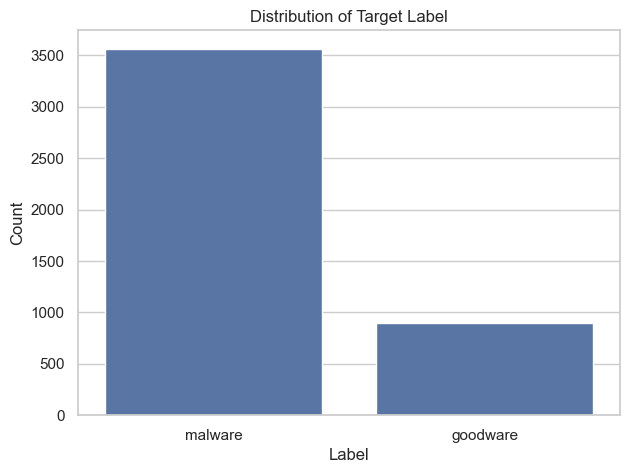

In [7]:

# Target 분포 시각화

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Distribution of Target Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


## 4. 결측치 확인

전체 결측치 수와 결측치가 있는 컬럼을 확인한다.  
이 데이터에서는 `Label`이 없는 행이 존재할 수 있으므로, target이 없는 행은 이후 분석에서 제외한다.


In [8]:

# ============================================================
# 4. 결측치 확인
# ============================================================

missing_count = df.isnull().sum()
missing_ratio = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio(%)": missing_ratio
}).sort_values(by="missing_count", ascending=False)

print("전체 결측치 개수:", df.isnull().sum().sum())
display(missing_df[missing_df["missing_count"] > 0])


전체 결측치 개수: 242


,missing_count,missing_ratio(%)
ACCESS_ALL_DOWNLOADS,1,0.022396
SUBSCRIBED_FEEDS_WRITE,1,0.022396
RECEIVE_USER_PRESENT,1,0.022396
RECEIVE_WAP_PUSH,1,0.022396
RECORD_AUDIO,1,0.022396
...,...,...
GET_PACKAGE_SIZE,1,0.022396
GET_TASKS,1,0.022396
GET_TOP_ACTIVITY_INFO,1,0.022396
GLOBAL_SEARCH,1,0.022396


In [9]:

# 결측치가 포함된 행 확인
display(df[df.isnull().any(axis=1)])


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,ACCESS_PROVIDER,ACCESS_SERVICE,ACCESS_SHARED_DATA,ACCESS_SUPERUSER,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,activityCalled,ACTIVITY_RECOGNITION,ACCOUNT_MANAGER,ADD_VOICEMAIL,ANT,ANT_ADMIN,AUTHENTICATE_ACCOUNTS,AUTORUN_MANAGER_LICENSE_MANAGER,AUTORUN_MANAGER_LICENSE_SERVICE(.autorun),BATTERY_STATS,BILLING,BIND_ACCESSIBILITY_SERVICE,BIND_APPWIDGET,BIND_CARRIER_MESSAGING_SERVICE,BIND_DEVICE_ADMIN,BIND_DREAM_SERVICE,BIND_GET_INSTALL_REFERRER_SERVICE,BIND_INPUT_METHOD,BIND_NFC_SERVICE,BIND_goodwareTIFICATION_LISTENER_SERVICE,BIND_PRINT_SERVICE,BIND_REMOTEVIEWS,BIND_TEXT_SERVICE,BIND_TV_INPUT,BIND_VOICE_INTERACTION,BIND_VPN_SERVICE,BIND_WALLPAPER,BLUETOOTH,BLUETOOTH_ADMIN,BLUETOOTH_PRIVILEGED,BODY_SENSORS,BRICK,BROADCAST_PACKAGE_REMOVED,BROADCAST_SMS,...,WRITE,WRITE_APN_SETTINGS,WRITE_AVSETTING,WRITE_CALENDAR,WRITE_CALL_LOG,WRITE_CONTACTS,WRITE_DATA,WRITE_DATABASES,WRITE_EXTERNAL_STORAGE,WRITE_GSERVICES,WRITE_HISTORY_BOOKMARKS,WRITE_INTERNAL_STORAGE,WRITE_MEDIA_STORAGE,WRITE_OWNER_DATA,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,WRITE_VOICEMAIL,Ljava/lang/reflect/Method;->invoke,Ljavax/crypto/Cipher;->doFinal,Ljava/lang/Runtime;->exec,Ljava/lang/System;->load,Ldalvik/system/DexClassLoader;->loadClass,Ljava/lang/System;->loadLibrary,Ljava/net/URL;->openConnection,Landroid/hardware/Camera;->open,Landroid/hardware/Camera;->takePicture,Landroid/telephony/SmsManager;->sendMultipartTextMessage,Landroid/telephony/SmsManager;->sendTextMessage,Landroid/media/AudioRecord;->startRecording,Landroid/telephony/TelephonyManager;->getCellLocation,Lcom/google/android/gms/location/LocationClient;->getLastLocation,Landroid/location/LocationManager;->getLastKgoodwarewnLocation,Landroid/telephony/TelephonyManager;->getDeviceId,Landroid/content/pm/PackageManager;->getInstalledApplications,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
2533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. 중복 데이터 확인 및 기본 정제

중복 행을 확인하고, target 값이 없는 행을 제거한다.  
중복 데이터는 EDA 관점에서는 먼저 확인만 하고, 원본 데이터 분포를 보존하기 위해 별도 제거하지 않는다.


In [10]:

# ============================================================
# 5. 중복 데이터 확인
# ============================================================

duplicate_count = df.duplicated().sum()
duplicate_ratio = duplicate_count / len(df) * 100

print("중복 행 개수:", duplicate_count)
print("중복 행 비율: {:.2f}%".format(duplicate_ratio))


중복 행 개수: 3802
중복 행 비율: 85.15%


In [11]:

# Label이 없는 행 제거

df_clean = df.dropna(subset=[target_col]).copy()

print("정제 전 데이터 크기:", df.shape)
print("정제 후 데이터 크기:", df_clean.shape)

print("\n정제 후 Label 분포:")
display(df_clean[target_col].value_counts())


정제 전 데이터 크기: (4465, 242)
정제 후 데이터 크기: (4464, 242)

정제 후 Label 분포:


Label
malware     3565
goodware     899
Name: count, dtype: int64

## 6. Feature와 Target 분리

데이터 설명 기준으로 1~214번째 feature는 Permission 기반 feature, 215~241번째 feature는 API 기반 feature로 구분한다.


In [12]:

# ============================================================
# 6. Feature와 Target 분리
# ============================================================

feature_cols = [col for col in df_clean.columns if col != target_col]

X = df_clean[feature_cols]
y = df_clean[target_col]

permission_cols = feature_cols[:214]
api_cols = feature_cols[214:]

print("전체 feature 개수:", len(feature_cols))
print("Permission feature 개수:", len(permission_cols))
print("API feature 개수:", len(api_cols))

print("\nPermission feature 예시:")
print(permission_cols[:10])

print("\nAPI feature 예시:")
print(api_cols[:10])


전체 feature 개수: 241
Permission feature 개수: 214
API feature 개수: 27

Permission feature 예시:
['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM', 'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION', 'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION', 'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION', 'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE']

API feature 예시:
['Ljava/lang/reflect/Method;->invoke', 'Ljavax/crypto/Cipher;->doFinal', 'Ljava/lang/Runtime;->exec', 'Ljava/lang/System;->load', 'Ldalvik/system/DexClassLoader;->loadClass', 'Ljava/lang/System;->loadLibrary', 'Ljava/net/URL;->openConnection', 'Landroid/hardware/Camera;->open', 'Landroid/hardware/Camera;->takePicture', 'Landroid/telephony/SmsManager;->sendMultipartTextMessage']


## 7. Feature 값의 특성 확인

대부분의 feature는 특정 권한 또는 API 호출 여부를 나타내는 0/1 binary feature다.


In [13]:

# ============================================================
# 7. Feature 값의 분포 확인
# ============================================================

nunique_df = pd.DataFrame({
    "feature": feature_cols,
    "n_unique": X[feature_cols].nunique().values
}).sort_values(by="n_unique", ascending=False)

print("고유값 개수별 feature 수:")
display(nunique_df["n_unique"].value_counts().sort_index())

display(nunique_df.head(20))


고유값 개수별 feature 수:


n_unique
1     42
2    199
Name: count, dtype: int64

,feature,n_unique
0,ACCESS_ALL_DOWNLOADS,2
168,SET_DEBUG_APP,2
154,RECEIVE_WAP_PUSH,2
155,RECORD_AUDIO,2
156,REORDER_TASKS,2
158,RESTART_PACKAGES,2
160,SDCARD_WRITE,2
162,SEND_RESPOND_VIA_MESSAGE,2
163,SEND_SMS,2
164,SET_ACTIVITY_WATCHER,2


In [14]:

# Feature 값이 0/1로만 구성되어 있는지 확인

binary_check = X[feature_cols].apply(lambda col: set(col.dropna().unique()).issubset({0, 1, 0.0, 1.0}))

print("Binary feature 개수:", binary_check.sum())
print("Non-binary feature 개수:", (~binary_check).sum())

if (~binary_check).sum() > 0:
    display(binary_check[binary_check == False])


Binary feature 개수: 241
Non-binary feature 개수: 0


## 8. 전체 Feature 사용 비율 분석

각 feature에서 값이 1인 비율을 계산한다.  
값이 1이라는 것은 해당 permission 또는 API feature가 존재한다는 의미로 볼 수 있다.


In [15]:

# ============================================================
# 8. 전체 Feature 사용 비율 분석
# ============================================================

feature_usage = X[feature_cols].mean().sort_values(ascending=False)

feature_usage_df = pd.DataFrame({
    "feature": feature_usage.index,
    "usage_ratio": feature_usage.values
})

display(feature_usage_df.head(20))


,feature,usage_ratio
0,WAKE_LOCK,0.885529
1,RECEIVE_BOOT_COMPLETED,0.843638
2,INTERNET,0.733647
3,GET_TASKS,0.641353
4,ACCESS_NETWORK_STATE,0.596326
5,Ljava/lang/reflect/Method;->invoke,0.550179
6,READ_PHONE_STATE,0.535394
7,Ljavax/crypto/Cipher;->doFinal,0.516577
8,KILL_BACKGROUND_PROCESSES,0.504256
9,WRITE_EXTERNAL_STORAGE,0.441308


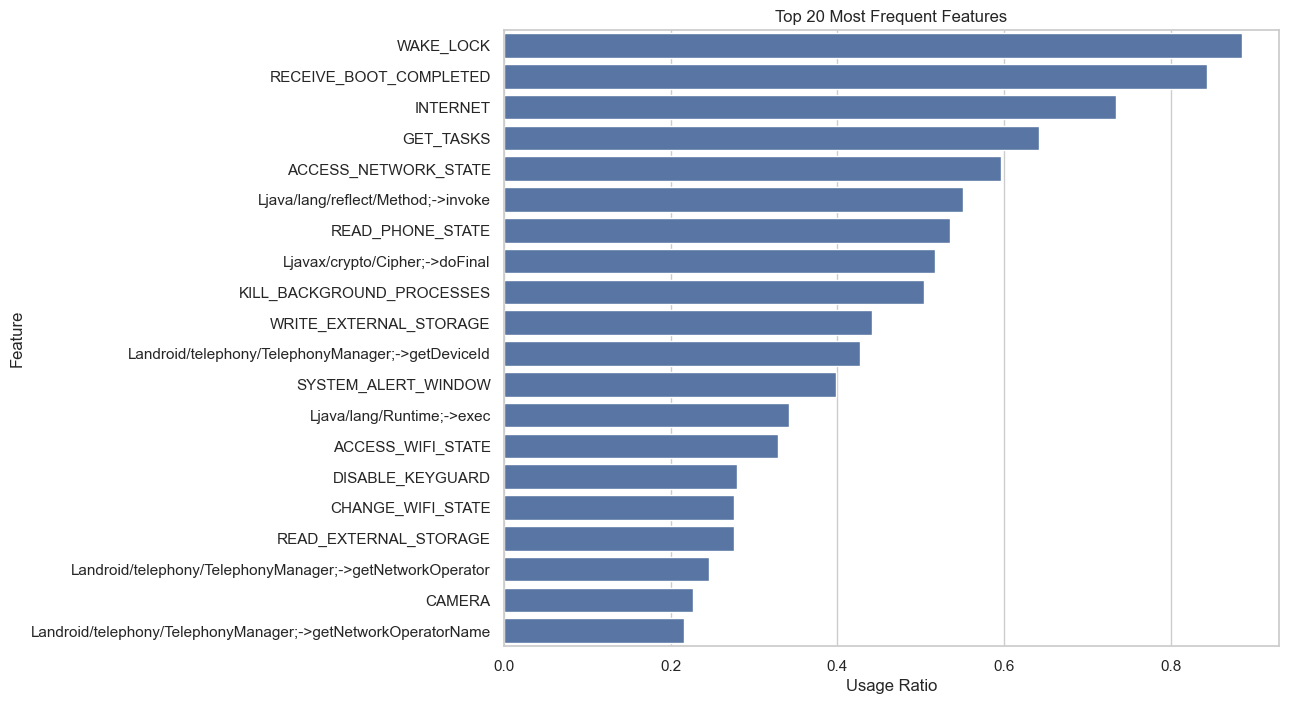

In [16]:

# 전체 데이터에서 가장 많이 등장하는 feature Top 20

top20_features = feature_usage.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top20_features.values, y=top20_features.index)
plt.title("Top 20 Most Frequent Features")
plt.xlabel("Usage Ratio")
plt.ylabel("Feature")
plt.show()


## 9. Permission Feature 사용 비율 분석

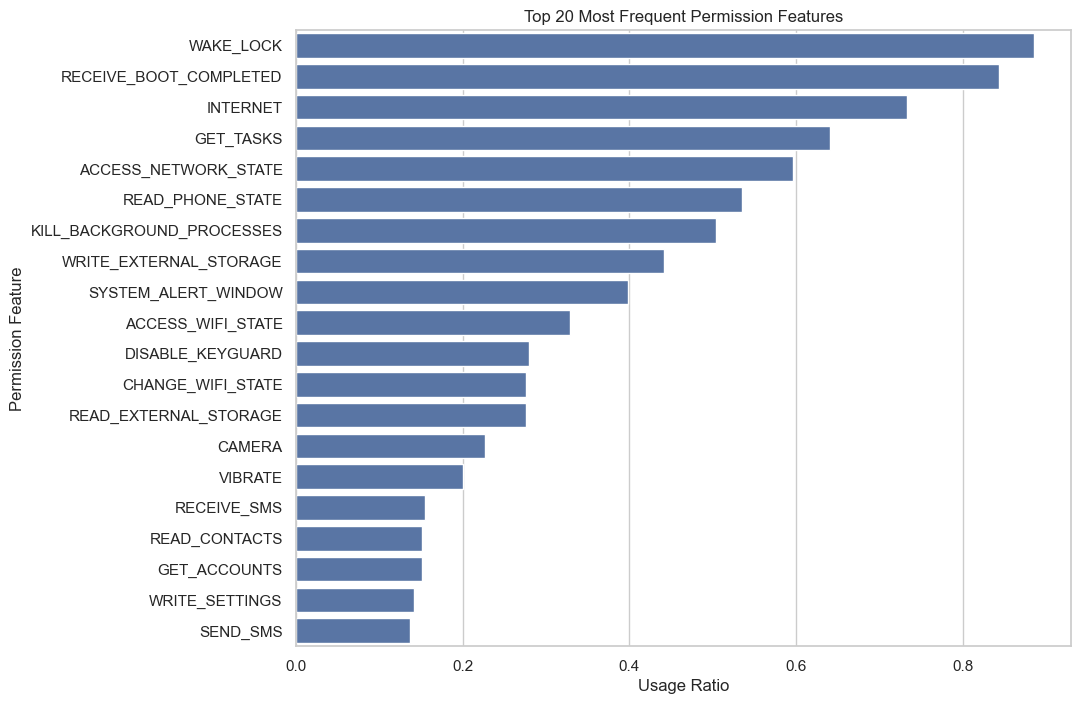

,usage_ratio
WAKE_LOCK,0.885529
RECEIVE_BOOT_COMPLETED,0.843638
INTERNET,0.733647
GET_TASKS,0.641353
ACCESS_NETWORK_STATE,0.596326
READ_PHONE_STATE,0.535394
KILL_BACKGROUND_PROCESSES,0.504256
WRITE_EXTERNAL_STORAGE,0.441308
SYSTEM_ALERT_WINDOW,0.398746
ACCESS_WIFI_STATE,0.328853


In [17]:

# ============================================================
# 9. Permission Feature 사용 비율 Top 20
# ============================================================

permission_usage = X[permission_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=permission_usage.head(20).values, y=permission_usage.head(20).index)
plt.title("Top 20 Most Frequent Permission Features")
plt.xlabel("Usage Ratio")
plt.ylabel("Permission Feature")
plt.show()

display(permission_usage.head(20).to_frame("usage_ratio"))


## 10. API Feature 사용 비율 분석

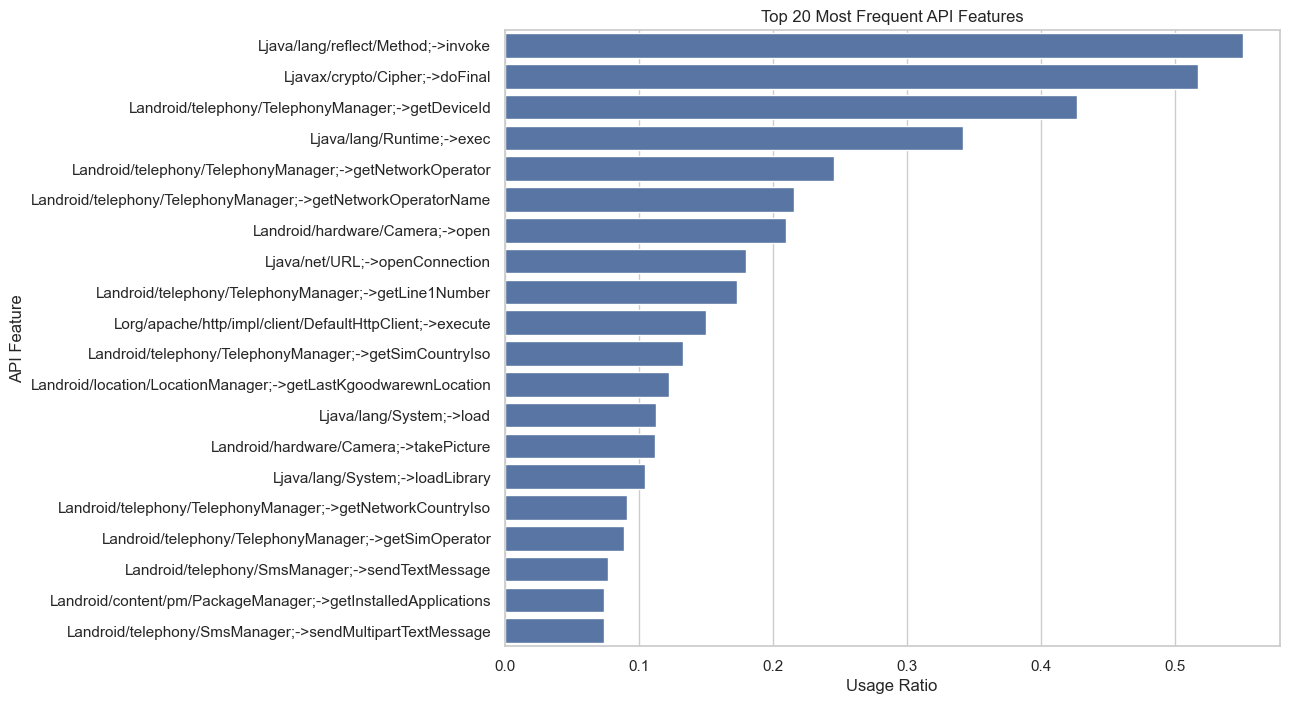

,usage_ratio
Ljava/lang/reflect/Method;->invoke,0.550179
Ljavax/crypto/Cipher;->doFinal,0.516577
Landroid/telephony/TelephonyManager;->getDeviceId,0.426971
Ljava/lang/Runtime;->exec,0.341398
Landroid/telephony/TelephonyManager;->getNetworkOperator,0.245520
Landroid/telephony/TelephonyManager;->getNetworkOperatorName,0.215950
Landroid/hardware/Camera;->open,0.209901
Ljava/net/URL;->openConnection,0.179659
Landroid/telephony/TelephonyManager;->getLine1Number,0.173163
Lorg/apache/http/impl/client/DefaultHttpClient;->execute,0.150090


In [18]:

# ============================================================
# 10. API Feature 사용 비율 Top 20
# ============================================================

api_usage = X[api_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=api_usage.head(20).values, y=api_usage.head(20).index)
plt.title("Top 20 Most Frequent API Features")
plt.xlabel("Usage Ratio")
plt.ylabel("API Feature")
plt.show()

display(api_usage.head(20).to_frame("usage_ratio"))


## 11. Malware와 Goodware의 Feature 사용 비율 비교

`malware`와 `goodware` 그룹별로 feature의 평균값을 계산한다.  
binary feature에서 평균값은 해당 feature가 등장한 비율로 해석할 수 있다.


In [19]:

# ============================================================
# 11. Malware와 Goodware의 Feature 사용 비율 비교
# ============================================================

group_feature_mean = df_clean.groupby(target_col)[feature_cols].mean()

display(group_feature_mean)


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,ACCESS_PROVIDER,ACCESS_SERVICE,ACCESS_SHARED_DATA,ACCESS_SUPERUSER,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,activityCalled,ACTIVITY_RECOGNITION,ACCOUNT_MANAGER,ADD_VOICEMAIL,ANT,ANT_ADMIN,AUTHENTICATE_ACCOUNTS,AUTORUN_MANAGER_LICENSE_MANAGER,AUTORUN_MANAGER_LICENSE_SERVICE(.autorun),BATTERY_STATS,BILLING,BIND_ACCESSIBILITY_SERVICE,BIND_APPWIDGET,BIND_CARRIER_MESSAGING_SERVICE,BIND_DEVICE_ADMIN,BIND_DREAM_SERVICE,BIND_GET_INSTALL_REFERRER_SERVICE,BIND_INPUT_METHOD,BIND_NFC_SERVICE,BIND_goodwareTIFICATION_LISTENER_SERVICE,BIND_PRINT_SERVICE,BIND_REMOTEVIEWS,BIND_TEXT_SERVICE,BIND_TV_INPUT,BIND_VOICE_INTERACTION,BIND_VPN_SERVICE,BIND_WALLPAPER,BLUETOOTH,BLUETOOTH_ADMIN,BLUETOOTH_PRIVILEGED,BODY_SENSORS,BRICK,BROADCAST_PACKAGE_REMOVED,BROADCAST_SMS,...,WAKE_LOCK,WRITE,WRITE_APN_SETTINGS,WRITE_AVSETTING,WRITE_CALENDAR,WRITE_CALL_LOG,WRITE_CONTACTS,WRITE_DATA,WRITE_DATABASES,WRITE_EXTERNAL_STORAGE,WRITE_GSERVICES,WRITE_HISTORY_BOOKMARKS,WRITE_INTERNAL_STORAGE,WRITE_MEDIA_STORAGE,WRITE_OWNER_DATA,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,WRITE_VOICEMAIL,Ljava/lang/reflect/Method;->invoke,Ljavax/crypto/Cipher;->doFinal,Ljava/lang/Runtime;->exec,Ljava/lang/System;->load,Ldalvik/system/DexClassLoader;->loadClass,Ljava/lang/System;->loadLibrary,Ljava/net/URL;->openConnection,Landroid/hardware/Camera;->open,Landroid/hardware/Camera;->takePicture,Landroid/telephony/SmsManager;->sendMultipartTextMessage,Landroid/telephony/SmsManager;->sendTextMessage,Landroid/media/AudioRecord;->startRecording,Landroid/telephony/TelephonyManager;->getCellLocation,Lcom/google/android/gms/location/LocationClient;->getLastLocation,Landroid/location/LocationManager;->getLastKgoodwarewnLocation,Landroid/telephony/TelephonyManager;->getDeviceId,Landroid/content/pm/PackageManager;->getInstalledApplications,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
Label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
goodware,0.004449,0.004449,0.000000,0.230256,0.000000,0.243604,0.010011,0.014461,0.001112,0.723026,0.0,0.0,0.0,0.004449,0.000000,0.402670,0.0,0.0,0.004449,0.000000,0.0,0.0,0.064516,0.0,0.0,0.042269,0.000000,0.010011,0.004449,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.002225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.114572,0.092325,0.000000,0.006674,0.000000,0.000000,0.000000,...,0.586207,0.0,0.007786,0.0,0.027809,0.001112,0.051168,0.0,0.0,0.639600,0.000000,0.000000,0.010011,0.011123,0.011123,0.012236,0.010011,0.113459,0.010011,0.006674,0.056730,0.011123,0.000000,0.707453,0.617353,0.30812,0.419355,0.272525,0.391546,0.724138,0.135706,0.058954,0.016685,0.024472,0.064516,0.082314,0.001112,0.549499,0.31257,0.157953,0.195773,0.125695,0.528365,0.408231,0.283648,0.295884,0.238042,0.269188,0.036707,0.151279
malware,0.000000,0.000000,0.006171,0.046283,0.008696,0.048527,0.026087,0.026087,0.000000,0.564376,0.0,0.0,0.0,0.001122,0.006171,0.310238,0.0,0.0,0.006171,0.026087,0.0,0.0,0.027489,0.0,0.0,0.088079,0.000561,0.006171,0.006171,0.006171,0.033661,0.006171,0.0,0.006171,0.006171,0.006171,0.006171,0.006171,0.006171,0.006171,0.006171,0.006171,0.006171,0.027489,0.026648,0.006171,0.006

In [20]:

# Malware와 Goodware 간 feature 사용 비율 차이 계산

malware_mean = group_feature_mean.loc["malware"]
goodware_mean = group_feature_mean.loc["goodware"]

diff_usage = malware_mean - goodware_mean

diff_usage_df = pd.DataFrame({
    "feature": diff_usage.index,
    "malware_usage": malware_mean.values,
    "goodware_usage": goodware_mean.values,
    "difference_malware_minus_goodware": diff_usage.values,
    "abs_difference": diff_usage.abs().values
}).sort_values(by="abs_difference", ascending=False)

display(diff_usage_df.head(30))


,feature,malware_usage,goodware_usage,difference_malware_minus_goodware,abs_difference
149,RECEIVE_BOOT_COMPLETED,0.982328,0.293660,0.688669,0.688669
220,Ljava/net/URL;->openConnection,0.042356,0.724138,-0.681782,0.681782
86,GET_TASKS,0.776999,0.103448,0.673550,0.673550
100,KILL_BACKGROUND_PROCESSES,0.614306,0.067853,0.546453,0.546453
228,Landroid/location/LocationManager;->getLastKgo...,0.014867,0.549499,-0.534633,0.534633
217,Ljava/lang/System;->load,0.035624,0.419355,-0.383731,0.383731
191,WAKE_LOCK,0.961010,0.586207,0.374803,0.374803
219,Ljava/lang/System;->loadLibrary,0.032258,0.391546,-0.359288,0.359288
233,Landroid/telephony/TelephonyManager;->getNetwo...,0.174194,0.528365,-0.354171,0.354171
182,SYSTEM_ALERT_WINDOW,0.467882,0.124583,0.343299,0.343299


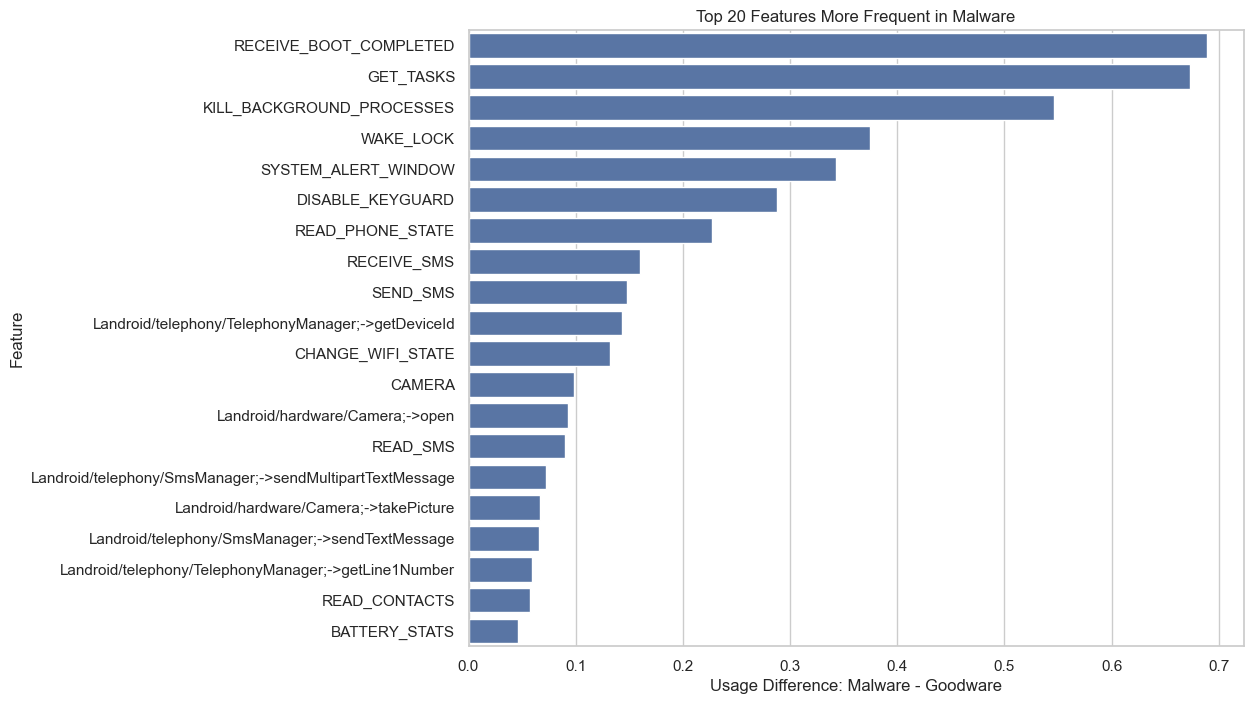

,malware_minus_goodware
RECEIVE_BOOT_COMPLETED,0.688669
GET_TASKS,0.673550
KILL_BACKGROUND_PROCESSES,0.546453
WAKE_LOCK,0.374803
SYSTEM_ALERT_WINDOW,0.343299
DISABLE_KEYGUARD,0.287953
READ_PHONE_STATE,0.227480
RECEIVE_SMS,0.160120
SEND_SMS,0.147991
Landroid/telephony/TelephonyManager;->getDeviceId,0.143251


In [21]:

# Malware에서 더 자주 나타나는 feature Top 20

malware_top = diff_usage.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=malware_top.values, y=malware_top.index)
plt.title("Top 20 Features More Frequent in Malware")
plt.xlabel("Usage Difference: Malware - Goodware")
plt.ylabel("Feature")
plt.show()

display(malware_top.to_frame("malware_minus_goodware"))


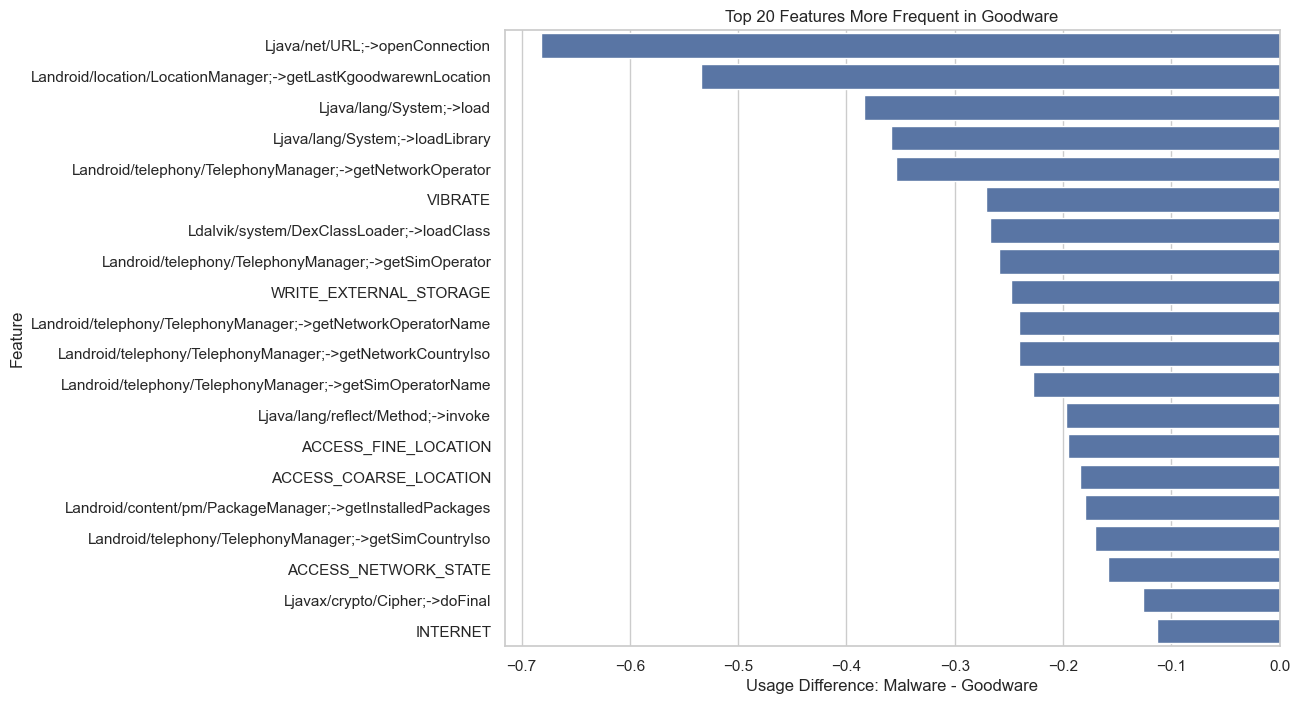

,malware_minus_goodware
Ljava/net/URL;->openConnection,-0.681782
Landroid/location/LocationManager;->getLastKgoodwarewnLocation,-0.534633
Ljava/lang/System;->load,-0.383731
Ljava/lang/System;->loadLibrary,-0.359288
Landroid/telephony/TelephonyManager;->getNetworkOperator,-0.354171
VIBRATE,-0.271548
Ldalvik/system/DexClassLoader;->loadClass,-0.267756
Landroid/telephony/TelephonyManager;->getSimOperator,-0.259419
WRITE_EXTERNAL_STORAGE,-0.248295
Landroid/telephony/TelephonyManager;->getNetworkOperatorName,-0.240770


In [22]:

# Goodware에서 더 자주 나타나는 feature Top 20

goodware_top = diff_usage.sort_values(ascending=True).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=goodware_top.values, y=goodware_top.index)
plt.title("Top 20 Features More Frequent in Goodware")
plt.xlabel("Usage Difference: Malware - Goodware")
plt.ylabel("Feature")
plt.show()

display(goodware_top.to_frame("malware_minus_goodware"))


## 12. Permission/API별 Malware-Goodware 차이 분석

,feature,difference_malware_minus_goodware,abs_difference
149,RECEIVE_BOOT_COMPLETED,0.688669,0.688669
86,GET_TASKS,0.673550,0.673550
100,KILL_BACKGROUND_PROCESSES,0.546453,0.546453
191,WAKE_LOCK,0.374803,0.374803
182,SYSTEM_ALERT_WINDOW,0.343299,0.343299
74,DISABLE_KEYGUARD,0.287953,0.287953
190,VIBRATE,-0.271548,0.271548
200,WRITE_EXTERNAL_STORAGE,-0.248295,0.248295
138,READ_PHONE_STATE,0.227480,0.227480
5,ACCESS_FINE_LOCATION,-0.195077,0.195077


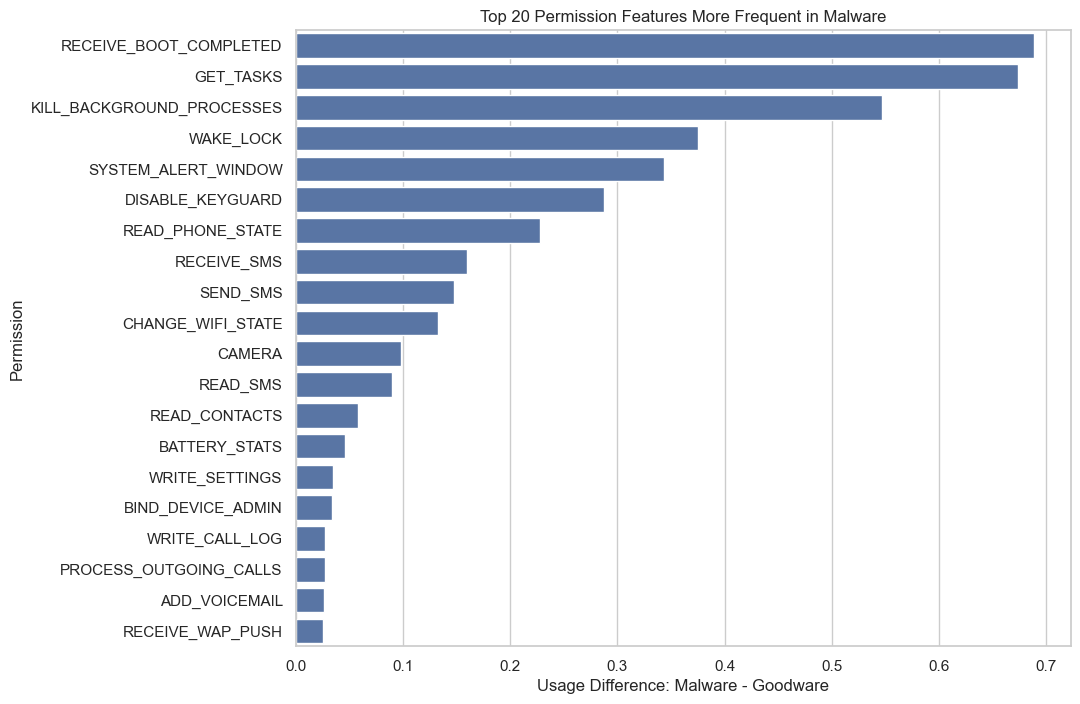

In [23]:

# ============================================================
# 12-1. Permission Feature 차이
# ============================================================

permission_diff = group_feature_mean[permission_cols].loc["malware"] - group_feature_mean[permission_cols].loc["goodware"]

permission_diff_df = pd.DataFrame({
    "feature": permission_diff.index,
    "difference_malware_minus_goodware": permission_diff.values,
    "abs_difference": permission_diff.abs().values
}).sort_values(by="abs_difference", ascending=False)

display(permission_diff_df.head(20))

permission_malware_top = permission_diff.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=permission_malware_top.values, y=permission_malware_top.index)
plt.title("Top 20 Permission Features More Frequent in Malware")
plt.xlabel("Usage Difference: Malware - Goodware")
plt.ylabel("Permission")
plt.show()


,feature,difference_malware_minus_goodware,abs_difference
6,Ljava/net/URL;->openConnection,-0.681782,0.681782
14,Landroid/location/LocationManager;->getLastKgo...,-0.534633,0.534633
3,Ljava/lang/System;->load,-0.383731,0.383731
5,Ljava/lang/System;->loadLibrary,-0.359288,0.359288
19,Landroid/telephony/TelephonyManager;->getNetwo...,-0.354171,0.354171
4,Ldalvik/system/DexClassLoader;->loadClass,-0.267756,0.267756
22,Landroid/telephony/TelephonyManager;->getSimOp...,-0.259419,0.259419
20,Landroid/telephony/TelephonyManager;->getNetwo...,-0.240770,0.240770
21,Landroid/telephony/TelephonyManager;->getNetwo...,-0.240451,0.240451
23,Landroid/telephony/TelephonyManager;->getSimOp...,-0.227664,0.227664


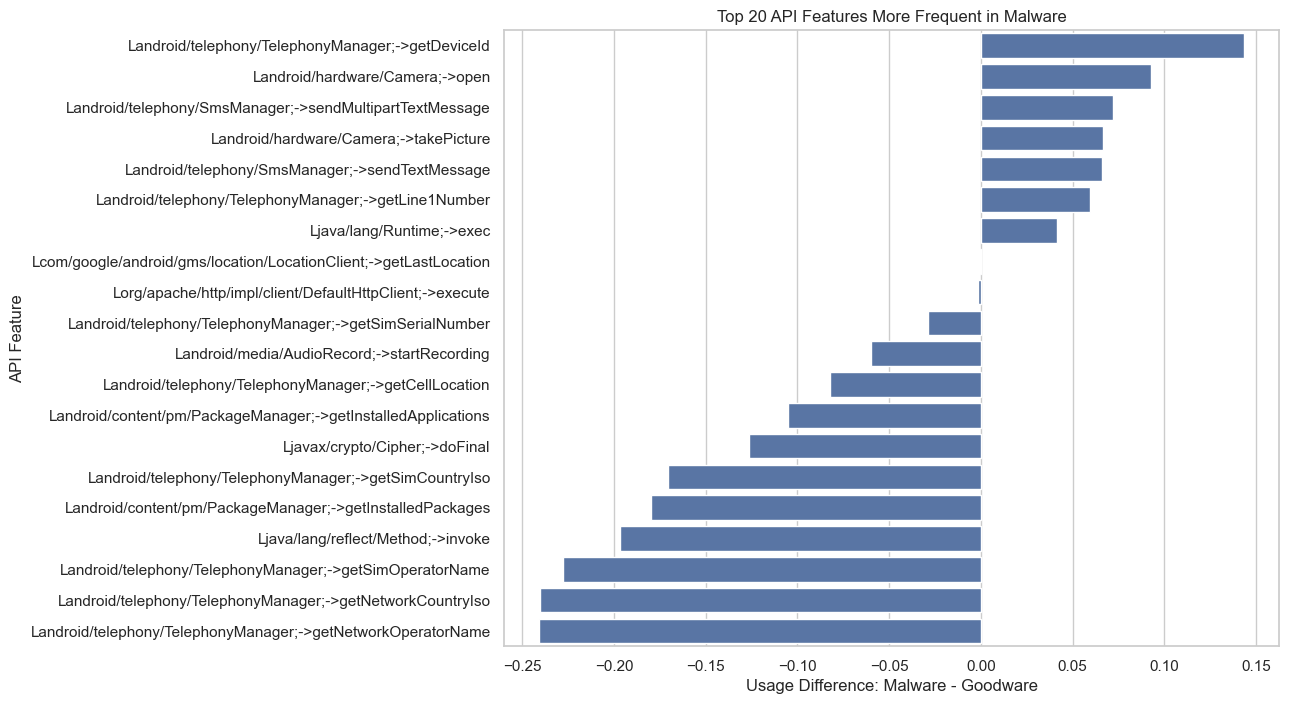

In [24]:

# ============================================================
# 12-2. API Feature 차이
# ============================================================

api_diff = group_feature_mean[api_cols].loc["malware"] - group_feature_mean[api_cols].loc["goodware"]

api_diff_df = pd.DataFrame({
    "feature": api_diff.index,
    "difference_malware_minus_goodware": api_diff.values,
    "abs_difference": api_diff.abs().values
}).sort_values(by="abs_difference", ascending=False)

display(api_diff_df.head(20))

api_malware_top = api_diff.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=api_malware_top.values, y=api_malware_top.index)
plt.title("Top 20 API Features More Frequent in Malware")
plt.xlabel("Usage Difference: Malware - Goodware")
plt.ylabel("API Feature")
plt.show()


## 13. 앱별 활성 Feature 개수 분석

각 앱이 보유한 permission/API feature의 개수를 계산하여 `malware`와 `goodware`의 차이를 비교한다.


In [25]:

# ============================================================
# 13. 앱별 feature 활성 개수 분석
# ============================================================

df_clean["total_feature_count"] = X[feature_cols].sum(axis=1)
df_clean["permission_count"] = X[permission_cols].sum(axis=1)
df_clean["api_count"] = X[api_cols].sum(axis=1)

display(df_clean[[target_col, "total_feature_count", "permission_count", "api_count"]].head())


,Label,total_feature_count,permission_count,api_count
0,malware,23.0,14.0,9.0
1,malware,10.0,7.0,3.0
2,malware,15.0,9.0,6.0
3,malware,14.0,6.0,8.0
4,malware,7.0,6.0,1.0


In [26]:

# Label별 feature 개수의 기초 통계량

count_summary = df_clean.groupby(target_col)[
    ["total_feature_count", "permission_count", "api_count"]
].agg(["mean", "median", "std", "min", "max"])

display(count_summary)


total_feature_count                               permission_count  \
                        mean median        std  min    max             mean   
Label                                                                         
goodware           15.474972   14.0  12.271801  0.0   98.0         8.097887   
malware            14.102384   10.0  15.493542  0.0  165.0        10.684712   

                                       api_count                              
         median        std  min    max      mean median       std  min   max  
Label                                                                         
goodware    6.0   8.564792  0.0   79.0  7.377086    7.0  5.493585  0.0  22.0  
malware     7.0  14.658664  0.0  152.0  3.417672    2.0  2.929545  0.0  19.0

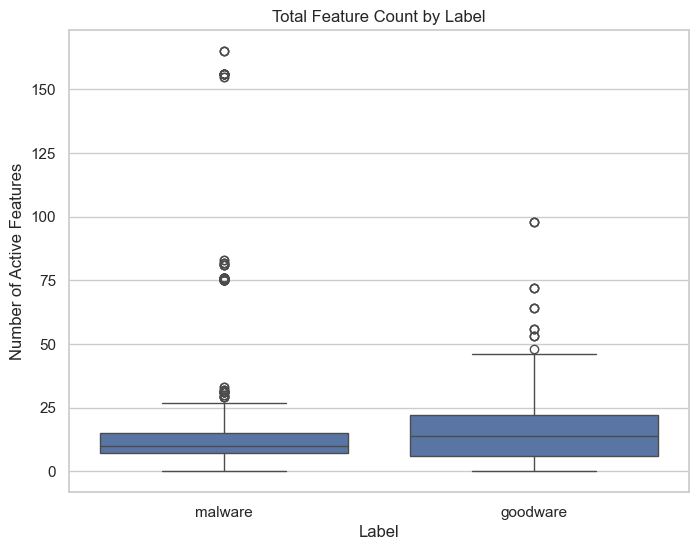

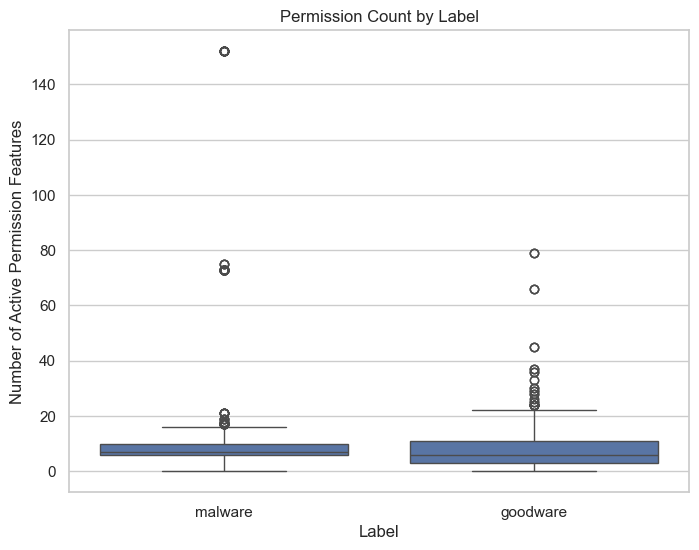

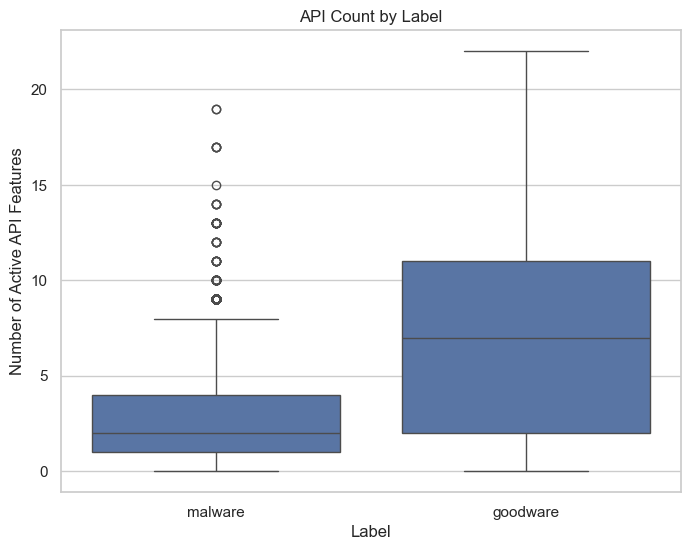

In [27]:

# Label별 전체 feature 개수 분포

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x=target_col, y="total_feature_count")
plt.title("Total Feature Count by Label")
plt.xlabel("Label")
plt.ylabel("Number of Active Features")
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x=target_col, y="permission_count")
plt.title("Permission Count by Label")
plt.xlabel("Label")
plt.ylabel("Number of Active Permission Features")
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x=target_col, y="api_count")
plt.title("API Count by Label")
plt.xlabel("Label")
plt.ylabel("Number of Active API Features")
plt.show()


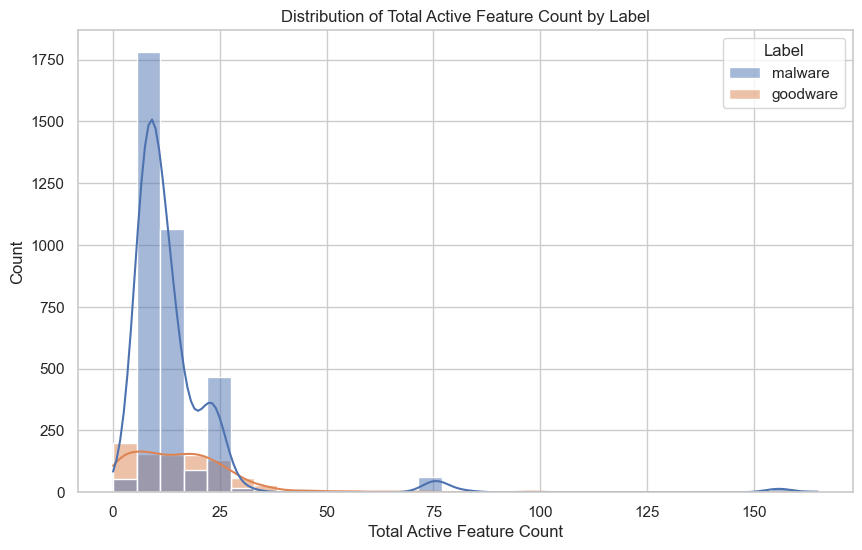

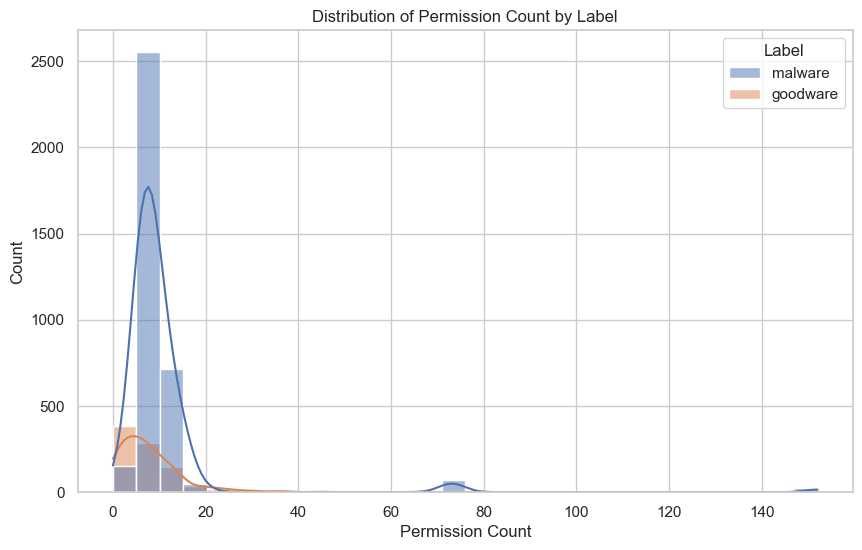

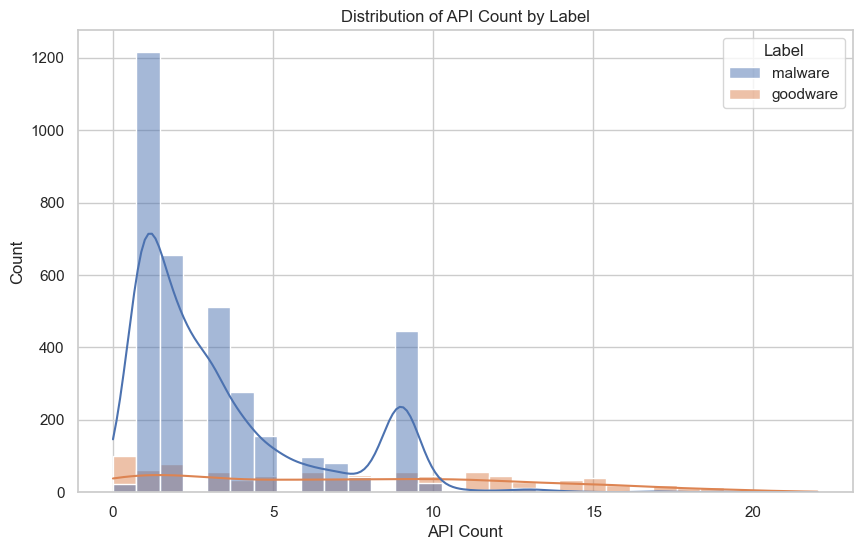

In [28]:

# Feature count 분포 히스토그램

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x="total_feature_count", hue=target_col, bins=30, kde=True)
plt.title("Distribution of Total Active Feature Count by Label")
plt.xlabel("Total Active Feature Count")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x="permission_count", hue=target_col, bins=30, kde=True)
plt.title("Distribution of Permission Count by Label")
plt.xlabel("Permission Count")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x="api_count", hue=target_col, bins=30, kde=True)
plt.title("Distribution of API Count by Label")
plt.xlabel("API Count")
plt.ylabel("Count")
plt.show()


## 14. Label과 Feature 간 상관관계 분석

`goodware = 0`, `malware = 1`로 변환한 뒤 feature와 label 사이의 상관관계를 계산한다.


In [29]:

# ============================================================
# 14. 상관관계 분석
# ============================================================

df_corr = df_clean.copy()
df_corr["label_binary"] = df_corr[target_col].map({
    "goodware": 0,
    "malware": 1
})

target_corr = df_corr[feature_cols + ["label_binary"]].corr(numeric_only=True)["label_binary"]
target_corr = target_corr.drop("label_binary").sort_values(key=abs, ascending=False)

target_corr_df = pd.DataFrame({
    "feature": target_corr.index,
    "correlation_with_malware": target_corr.values,
    "abs_correlation": target_corr.abs().values
}).sort_values(by="abs_correlation", ascending=False)

display(target_corr_df.head(30))


,feature,correlation_with_malware,abs_correlation
0,RECEIVE_BOOT_COMPLETED,0.760417,0.760417
1,Ljava/net/URL;->openConnection,-0.712211,0.712211
2,Landroid/location/LocationManager;->getLastKgo...,-0.653875,0.653875
3,GET_TASKS,0.563214,0.563214
4,Ljava/lang/System;->load,-0.486265,0.486265
5,WAKE_LOCK,0.472105,0.472105
6,Ljava/lang/System;->loadLibrary,-0.470790,0.470790
7,Ldalvik/system/DexClassLoader;->loadClass,-0.456847,0.456847
8,KILL_BACKGROUND_PROCESSES,0.438312,0.438312
9,Landroid/telephony/TelephonyManager;->getSimOp...,-0.396342,0.396342


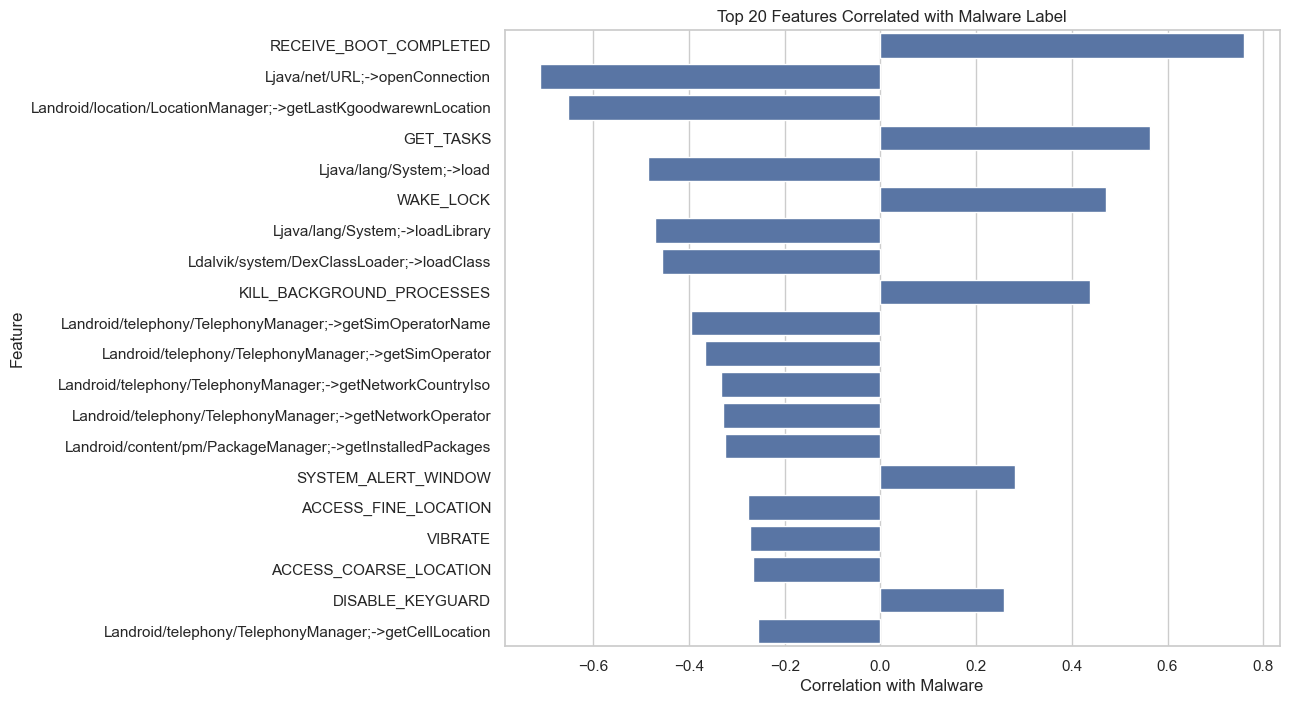

In [30]:

# Malware label과 상관관계가 높은 feature Top 20

top_corr = target_corr_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_corr,
    x="correlation_with_malware",
    y="feature"
)
plt.title("Top 20 Features Correlated with Malware Label")
plt.xlabel("Correlation with Malware")
plt.ylabel("Feature")
plt.show()


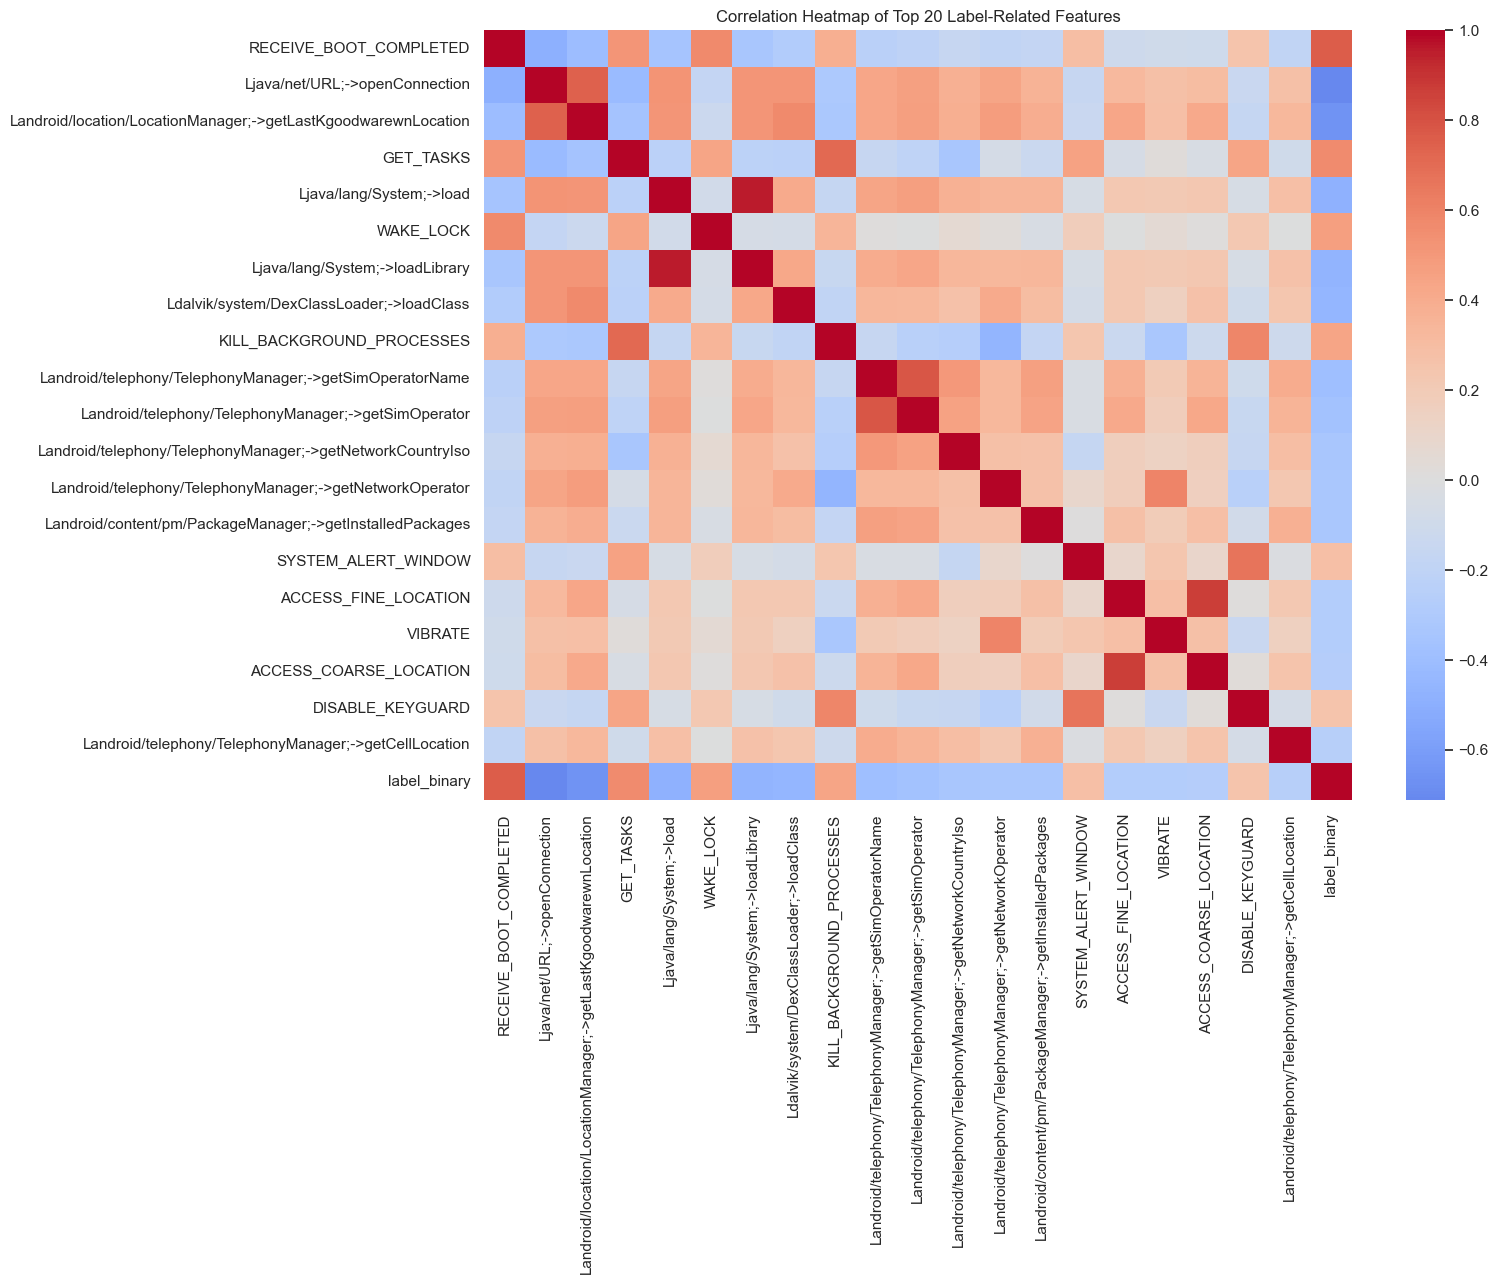

In [31]:

# 주요 feature 간 상관관계 Heatmap
# 전체 feature를 모두 표시하면 복잡하므로 label과 상관관계가 높은 상위 20개 feature만 사용한다.

top_corr_features = target_corr_df.head(20)["feature"].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_corr[top_corr_features + ["label_binary"]].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Top 20 Label-Related Features")
plt.show()


## 15. 희소 Feature와 공통 Feature 분석

거의 등장하지 않는 feature와 거의 모든 앱에 등장하는 feature를 확인한다.


In [32]:

# ============================================================
# 15. 희소 Feature 분석
# ============================================================

rare_features = feature_usage_df[feature_usage_df["usage_ratio"] < 0.01]
common_features = feature_usage_df[feature_usage_df["usage_ratio"] > 0.90]

print("1% 미만으로 등장하는 희소 feature 개수:", len(rare_features))
print("90% 이상으로 등장하는 공통 feature 개수:", len(common_features))

print("\n희소 feature 예시:")
display(rare_features.head(20))

print("\n공통 feature:")
display(common_features)


1% 미만으로 등장하는 희소 feature 개수: 139
90% 이상으로 등장하는 공통 feature 개수: 0

희소 feature 예시:


,feature,usage_ratio
102,USE_FINGERPRINT,0.008513
103,WRITE_SECURE_SETTINGS,0.007616
104,DELETE_PACKAGES,0.007168
105,CLEAR_APP_USER_DATA,0.006944
106,ACCESS_COARSE_UPDATES,0.006944
107,BIND_ACCESSIBILITY_SERVICE,0.006944
108,INSTALL_PACKAGES,0.006720
109,MASTER_CLEAR,0.006496
110,WRITE_APN_SETTINGS,0.006496
111,BODY_SENSORS,0.006272



공통 feature:


,feature,usage_ratio


## 16. EDA 요약

분석 결과를 표와 문장으로 정리한다.


In [33]:

# ============================================================
# 16. EDA 요약 테이블
# ============================================================

eda_summary_table = pd.DataFrame({
    "total_rows": [len(df_clean)],
    "total_features": [len(feature_cols)],
    "permission_features": [len(permission_cols)],
    "api_features": [len(api_cols)],
    "malware_count": [(df_clean[target_col] == "malware").sum()],
    "goodware_count": [(df_clean[target_col] == "goodware").sum()],
    "missing_rows_removed": [len(df) - len(df_clean)],
    "duplicated_rows_raw": [duplicate_count]
})

display(eda_summary_table)


,total_rows,total_features,permission_features,api_features,malware_count,goodware_count,missing_rows_removed,duplicated_rows_raw
0,4464,241,214,27,3565,899,1,3802


In [34]:

# 최종 EDA 요약 출력

malware_ratio = (df_clean[target_col] == "malware").mean() * 100
goodware_ratio = (df_clean[target_col] == "goodware").mean() * 100

print("========== EDA Summary ==========")
print(f"1. 데이터는 총 {df_clean.shape[0]}개 행과 {len(feature_cols)}개의 feature로 구성되어 있다.")
print("2. Target 변수는 malware/goodware 이진 분류 형태이다.")
print(f"3. Malware 비율은 약 {malware_ratio:.2f}%, Goodware 비율은 약 {goodware_ratio:.2f}%이다.")
print(f"4. Feature는 Permission 기반 feature {len(permission_cols)}개와 API 기반 feature {len(api_cols)}개로 나눌 수 있다.")
print("5. 대부분의 feature는 0 또는 1 값을 가지는 binary feature이다.")
print("6. Malware와 Goodware 간 사용 비율 차이가 큰 feature는 악성 앱 탐지에 중요한 후보 feature로 볼 수 있다.")
print("7. Feature count, 개별 feature 사용 비율, label과의 상관관계를 함께 보면 malware/goodware의 차이를 더 명확하게 확인할 수 있다.")

print("\n[가장 자주 등장하는 feature Top 5]")
print(feature_usage.head(5))

print("\n[Malware와 Goodware 간 차이가 큰 feature Top 5]")
print(diff_usage_df.head(5)[["feature", "malware_usage", "goodware_usage", "difference_malware_minus_goodware"]])

print("\n[Label과 상관관계가 높은 feature Top 5]")
print(target_corr_df.head(5)[["feature", "correlation_with_malware"]])


========== EDA Summary ==========
1. 데이터는 총 4464개 행과 241개의 feature로 구성되어 있다.
2. Target 변수는 malware/goodware 이진 분류 형태이다.
3. Malware 비율은 약 79.86%, Goodware 비율은 약 20.14%이다.
4. Feature는 Permission 기반 feature 214개와 API 기반 feature 27개로 나눌 수 있다.
5. 대부분의 feature는 0 또는 1 값을 가지는 binary feature이다.
6. Malware와 Goodware 간 사용 비율 차이가 큰 feature는 악성 앱 탐지에 중요한 후보 feature로 볼 수 있다.
7. Feature count, 개별 feature 사용 비율, label과의 상관관계를 함께 보면 malware/goodware의 차이를 더 명확하게 확인할 수 있다.

[가장 자주 등장하는 feature Top 5]
WAKE_LOCK                 0.885529
RECEIVE_BOOT_COMPLETED    0.843638
INTERNET                  0.733647
GET_TASKS                 0.641353
ACCESS_NETWORK_STATE      0.596326
dtype: float64

[Malware와 Goodware 간 차이가 큰 feature Top 5]
                                               feature  malware_usage  \
149                             RECEIVE_BOOT_COMPLETED       0.982328   
220                     Ljava/net/URL;->openConnection       0.042356   
86                                           GET_TASKS      